In [ ]:
!wget https://raw.githubusercontent.com/phonetics-spbu/phonetics-spbu.github.io/main/public/courses/dsp/audio/cta0001.wav

In [72]:
import numpy as np
import librosa
import soundfile as sf

y, sr = librosa.load("cta0001.wav")

# 1. Делаем прямое преобразование Фурье (STFT)
# Получаем:
# S_complex = A * exp(j * phase)
S_complex = librosa.stft(y)

# 2. Разделяем на амплитуду и фазу
S_ampl, S_phase = librosa.magphase(S_complex)

# 3. Создаем случайную фазу
random_phase = np.exp(1.0j * np.random.uniform(0, 2*np.pi, S_complex.shape))

# 4. Собираем обратно: старая амплитуда + случайная фаза
S_random = S_ampl * random_phase
y_random = librosa.istft(S_random)

# 5. Сохраняем результаты для сравнения
sf.write('original.wav', y, sr)
sf.write('random_phase.wav', y_random, sr)

In [73]:
from IPython.display import Audio

Audio(y, rate=sr)

In [74]:
Audio(y_random, rate=sr)

Text(0.5, 1.0, 'Со случайной фазой')

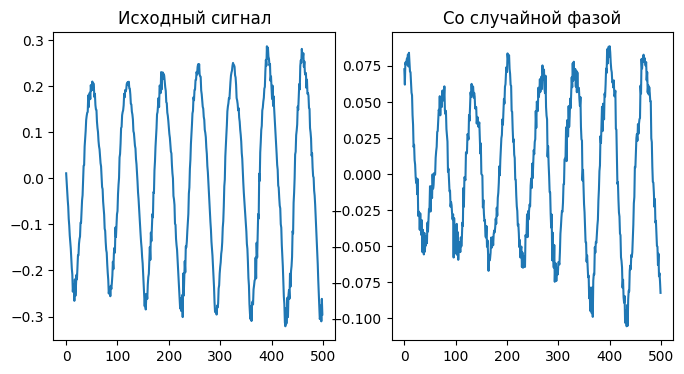

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(y[5500:6000])
plt.title('Исходный сигнал')

plt.subplot(1, 2, 2)
plt.plot(y_random[5500:6000])
plt.title('Со случайной фазой')

Text(0.5, 1.0, 'Со случайной фазой')

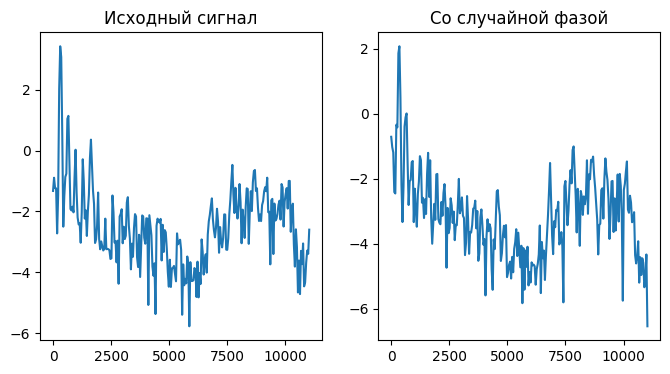

In [76]:
from scipy.fft import rfft, rfftfreq
import numpy as np

plt.figure(figsize=(8, 4))

orig_spectrum = np.log(np.abs(rfft(y[5500:6000] * np.hamming(500))))
new_spectrum = np.log(np.abs(rfft(y_random[5500:6000] * np.hamming(500))))

freqs = rfftfreq(500, 1 / sr)

plt.subplot(1, 2, 1)
plt.plot(freqs, orig_spectrum)
plt.title('Исходный сигнал')

plt.subplot(1, 2, 2)
plt.plot(freqs, new_spectrum)
plt.title('Со случайной фазой')

In [77]:
# 2 итерации
y_2 = librosa.griffinlim(S_ampl, n_iter=2)

Audio(y_2, rate=sr)

In [78]:
# 8 итерации
y_8 = librosa.griffinlim(S_ampl, n_iter=8)

Audio(y_8, rate=sr)

In [79]:
# 16 итераций
y_16 = librosa.griffinlim(S_ampl, n_iter=16)

Audio(y_16, rate=sr)

In [80]:
# 100 итераций
y_100 = librosa.griffinlim(S_ampl, n_iter=100)

Audio(y_100, rate=sr)

Text(0.5, 1.0, '100 итераций')

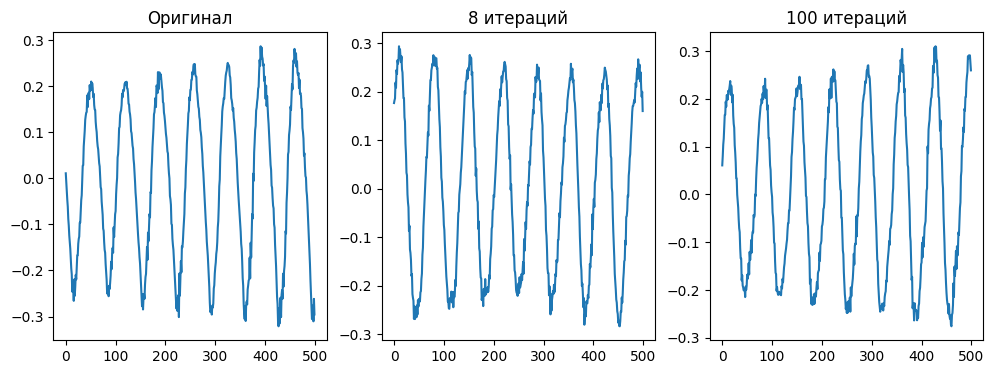

In [81]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(y[5500:6000])
plt.title('Оригинал')

plt.subplot(1, 3, 2)
plt.plot(y_8[5500:6000])
plt.title('8 итераций')

plt.subplot(1, 3, 3)
plt.plot(y_100[5500:6000])
plt.title('100 итераций')

Text(0.5, 1.0, '100 итераций')

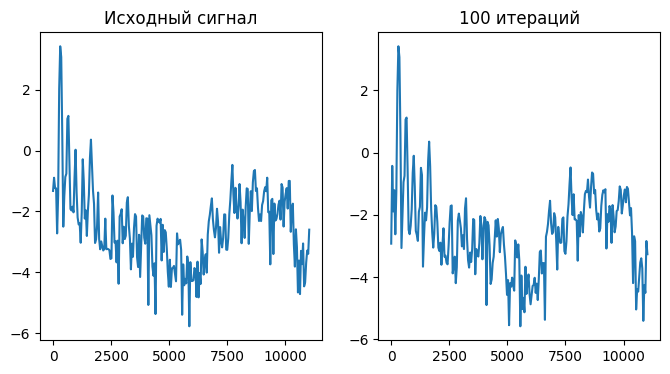

In [82]:
spectrum_100 = np.log(np.abs(rfft(y_100[5500:6000] * np.hamming(500))))

freqs = rfftfreq(500, 1 / sr)

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.plot(freqs, orig_spectrum)
plt.title('Исходный сигнал')

plt.subplot(1, 2, 2)
plt.plot(freqs, spectrum_100)
plt.title('100 итераций')

In [83]:
def griffin_lim_custom(spectrogram, n_iter, hop_length=512, win_length=2048):
    """
    Реализация алгоритма Гриффина-Лима.
    """
    # Генерируем случайную фазу
    random_phase = np.exp(2j * np.pi * np.random.rand(*spectrogram.shape))

    # Объединяем амплитуду и случайную фазу в комплексное число
    stft_matrix = spectrogram * random_phase

    # Итерации
    for i in range(n_iter):
        # Обратное преобразование Фурье
        signal = librosa.istft(stft_matrix, hop_length=hop_length, win_length=win_length)

        # Снова делаем прямое преобразование Фурье
        # Получаем новую фазу, которая чуть должна быть чуть лучше предыдущего варианта
        new_stft = librosa.stft(signal, n_fft=win_length, hop_length=hop_length, win_length=win_length)

        # Выделяем фазу
        phase = np.exp(1j * np.angle(new_stft))

        # Обновляем спектр: берем исходную амплитуду и новую фазу
        stft_matrix = spectrogram * phase

    # Обратное преобразование из того, что получилось после итераций
    return librosa.istft(stft_matrix, hop_length=hop_length, win_length=win_length)

In [84]:
S_complex = np.abs(librosa.stft(y))

y_recovered = griffin_lim_custom(S_complex, n_iter=100)

Audio(y_recovered, rate=sr)